# Network Intrusion Detection using Logistic Regression and Decision Tree

This notebook demonstrates training and evaluating both a **Logistic Regression** model and a **Decision Tree** classifier following a structured step-by-step workflow.

In [2]:
import sys
import time
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

# Add src to path for imports
sys.path.insert(0, str(Path.cwd()))

from src.model_training import (
    load_and_split,
    evaluate_model,
    plot_confusion_matrix,
    compare_models
)

# STEP 1: Load & split dataset
print("="*70)
print("STEP 1: Loading and splitting the CICIDS2017 cleaned dataset")
print("="*70)

X_train, X_test, y_train, y_test = load_and_split(
    data_path="cicids2017_cleaned.csv",
    target_col="Attack Type",
    test_size=0.2,
    random_state=42,
    save=False
)

print(f"\nFeature columns: {X_train.shape[1]}")
print(f"Classes: {sorted(y_train.unique())}")

STEP 1: Loading and splitting the CICIDS2017 cleaned dataset
Loading data from: cicids2017_cleaned.csv
 → Loaded 2,520,762 rows × 53 columns

Class distribution (%):
                             Full  Train   Test
Attack Type                                    
BENIGN                      83.11  83.11  83.11
DoS                          7.69   7.69   7.69
DDoS                         5.08   5.08   5.08
PortScan                     3.60   3.60   3.60
Brute Force                  0.36   0.36   0.36
Bot                          0.08   0.08   0.08
Web Attack � Brute Force     0.06   0.06   0.06
Web Attack � XSS             0.03   0.03   0.03
Web Attack � Sql Injection   0.00   0.00   0.00
Heartbleed                   0.00   0.00   0.00

Train size: 2,016,609  |  Test size: 504,153


Feature columns: 52
Classes: ['BENIGN', 'Bot', 'Brute Force', 'DDoS', 'DoS', 'Heartbleed', 'PortScan', 'Web Attack � Brute Force', 'Web Attack � Sql Injection', 'Web Attack � XSS']


In [3]:
# Inspect training class distribution (percentages)
print("\nClass distribution in training set (%):")
print(y_train.value_counts(normalize=True).mul(100).round(2))


Class distribution in training set (%):
Attack Type
BENIGN                        83.11
DoS                            7.69
DDoS                           5.08
PortScan                       3.60
Brute Force                    0.36
Bot                            0.08
Web Attack � Brute Force       0.06
Web Attack � XSS               0.03
Web Attack � Sql Injection     0.00
Heartbleed                     0.00
Name: proportion, dtype: float64


In [4]:
# Scaler 
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)


In [5]:
# import pandas as pd
# pd.DataFrame(X_train_scaled, columns=X_train.columns).describe()

In [6]:
print("\n" + "="*70)
print("STEP 2: Training Logistic Regression")
print("="*70)

t0 = time.time()
lr_model = LogisticRegression(max_iter=100, solver="lbfgs", random_state=42, n_jobs=-1)
print("Fitting logistic regression on scaled training data...")
lr_model.fit(X_train_scaled, y_train)
train_time_lr = time.time() - t0
print(f"\n✓ Training completed in {train_time_lr:.2f} seconds")
print("Number of iterations:", lr_model.n_iter_)


STEP 2: Training Logistic Regression
Fitting logistic regression on scaled training data...

✓ Training completed in 68.26 seconds
Number of iterations: [100]



STEP 3: Evaluate Logistic Regression

  Logistic Regression — Evaluation Results
                            precision    recall  f1-score   support

                    BENIGN       0.99      0.98      0.98    419012
                       Bot       0.24      0.02      0.04       390
               Brute Force       0.95      0.75      0.84      1830
                      DDoS       0.99      0.96      0.97     25603
                       DoS       0.98      0.92      0.95     38749
                Heartbleed       0.00      0.00      0.00         2
                  PortScan       0.72      0.99      0.83     18139
  Web Attack � Brute Force       0.00      0.00      0.00       294
Web Attack � Sql Injection       0.00      0.00      0.00         4
          Web Attack � XSS       0.00      0.00      0.00       130

                  accuracy                           0.97    504153
                 macro avg       0.49      0.46      0.46    504153
              weighted avg      

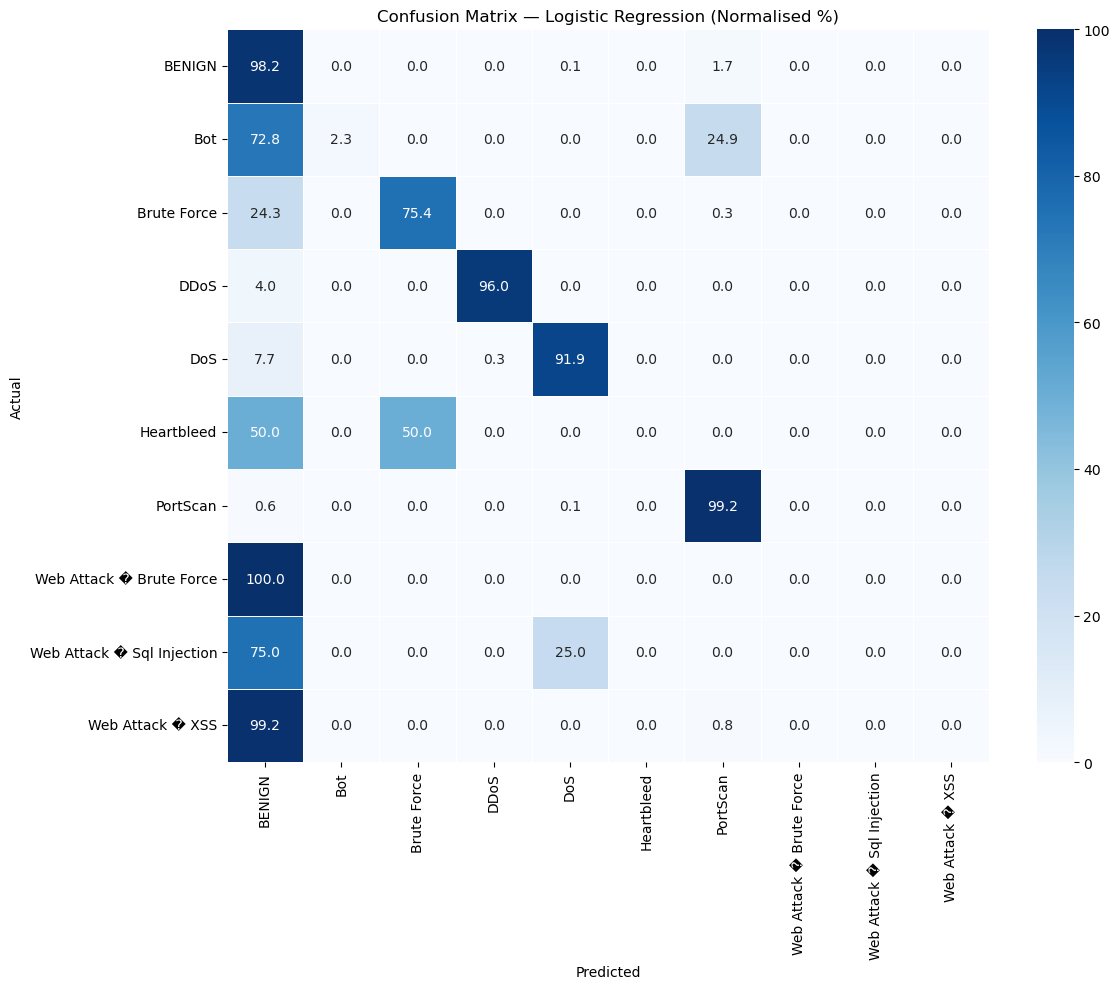

In [7]:
print("\n" + "="*70)
print("STEP 3: Evaluate Logistic Regression")
print("="*70)

# scale test set
X_test_scaled = scaler.transform(X_test)

y_pred_lr = lr_model.predict(X_test_scaled)
y_proba_lr = lr_model.predict_proba(X_test_scaled)

lr_results = evaluate_model(
    y_true=y_test,
    y_pred=y_pred_lr,
    model_name="Logistic Regression",
    y_pred_proba=y_proba_lr,
    labels=lr_model.classes_.tolist(),
    print_report=True
)

print("\n" + "="*70)
print("STEP 4: Confusion Matrix - Logistic Regression")
print("="*70)
plot_confusion_matrix(
    y_true=y_test,
    y_pred=y_pred_lr,
    labels=lr_model.classes_.tolist(),
    model_name="Logistic Regression",
    normalize=True,
    figsize=(12, 10),
    save_path=None
)

In [8]:
print("\n" + "="*70)
print("STEP 5: Training Decision Tree Classifier")
print("="*70)

t0 = time.time()
dt_model = DecisionTreeClassifier(random_state=42, max_depth=20)
print("Fitting decision tree on unscaled training data...")
dt_model.fit(X_train, y_train)
train_time_dt = time.time() - t0
print(f"\n✓ Training completed in {train_time_dt:.2f} seconds")


STEP 5: Training Decision Tree Classifier
Fitting decision tree on unscaled training data...

✓ Training completed in 114.82 seconds



STEP 6: Evaluate Decision Tree

  Decision Tree (depth=20) — Evaluation Results
                            precision    recall  f1-score   support

                    BENIGN       1.00      1.00      1.00    419012
                       Bot       0.73      0.74      0.73       390
               Brute Force       1.00      1.00      1.00      1830
                      DDoS       1.00      1.00      1.00     25603
                       DoS       1.00      1.00      1.00     38749
                Heartbleed       1.00      0.50      0.67         2
                  PortScan       0.99      0.99      0.99     18139
  Web Attack � Brute Force       0.71      0.77      0.74       294
Web Attack � Sql Injection       1.00      0.25      0.40         4
          Web Attack � XSS       0.38      0.27      0.31       130

                  accuracy                           1.00    504153
                 macro avg       0.88      0.75      0.78    504153
              weighted avg       

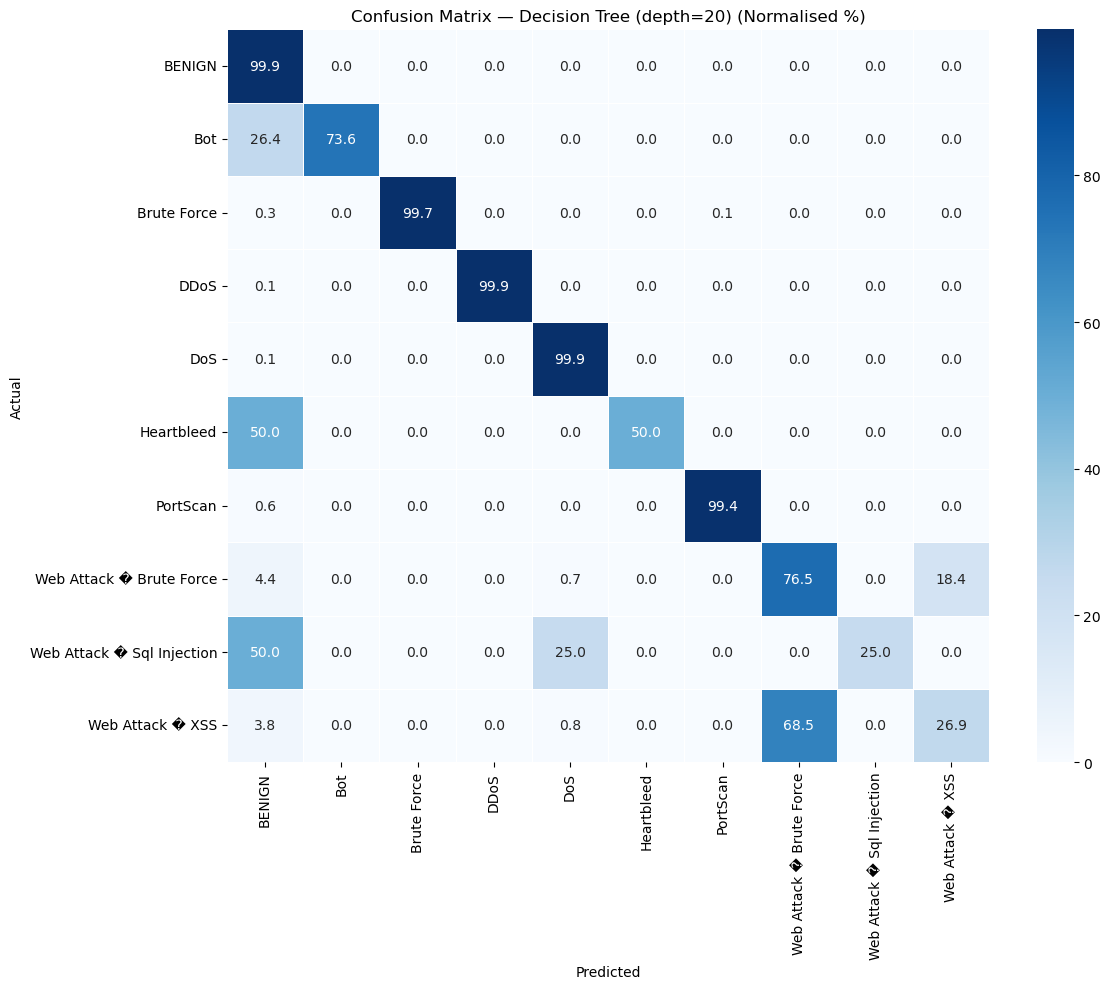

In [9]:
print("\n" + "="*70)
print("STEP 6: Evaluate Decision Tree")
print("="*70)

y_pred_dt = dt_model.predict(X_test)
y_proba_dt = dt_model.predict_proba(X_test)

dt_results = evaluate_model(
    y_true=y_test,
    y_pred=y_pred_dt,
    model_name="Decision Tree (depth=20)",
    y_pred_proba=y_proba_dt,
    labels=dt_model.classes_.tolist(),
    print_report=True
)

print("\n" + "="*70)
print("STEP 7: Confusion Matrix - Decision Tree")
print("="*70)
plot_confusion_matrix(
    y_true=y_test,
    y_pred=y_pred_dt,
    labels=dt_model.classes_.tolist(),
    model_name="Decision Tree (depth=20)",
    normalize=True,
    figsize=(12, 10),
    save_path=None
)

In [10]:
print("\n" + "="*70)
print("STEP 8: Model Comparison Summary")
print("="*70)

comparison_df = compare_models([lr_results, dt_results])
print("\nModel Comparison Results:")
print(comparison_df.to_string(index=False))

print("\n" + "="*70)
print("Training Summary")
print("="*70)
print(f"Logistic Regression training time: {train_time_lr:.2f} seconds")
print(f"Decision Tree training time: {train_time_dt:.2f} seconds")
print(f"Test set size: {len(y_test):,} samples")
print(f"Number of features: {X_train.shape[1]}")
print(f"Number of classes: {len(dt_model.classes_)}")


STEP 8: Model Comparison Summary

Model Comparison Results:
                   Model  Accuracy  Precision (weighted)  Precision (macro)  Recall (weighted)  Recall (macro)  F1 (weighted)  F1 (macro)  Cohen Kappa    MCC  ROC-AUC (weighted)  ROC-AUC (macro)
Decision Tree (depth=20)    0.9983                0.9983             0.8797             0.9983          0.7508         0.9983      0.7834       0.9944 0.9944              0.9988           0.9548
     Logistic Regression    0.9737                0.9760             0.4876             0.9737          0.4629         0.9738      0.4627       0.9132 0.9137              0.9950           0.9141

Training Summary
Logistic Regression training time: 68.26 seconds
Decision Tree training time: 114.82 seconds
Test set size: 504,153 samples
Number of features: 52
Number of classes: 10
